In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import gc
from tabulate import tabulate

# Scikit-learn components
from sklearn import preprocessing
from sklearn.cluster import DBSCAN
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelBinarizer, MinMaxScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    classification_report, 
    confusion_matrix, 
    accuracy_score, 
    precision_score, 
    recall_score, 
    f1_score
)

# TensorFlow/Keras components
import tensorflow as tf
from tensorflow.keras.utils import to_categorical, plot_model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv1D, 
    MaxPooling1D, 
    Flatten, 
    Dense, 
    Dropout
)
from tensorflow.keras.applications import VGG16
from tensorflow.keras.utils import Sequence

# XGBoost and other ML libraries
from xgboost import XGBClassifier
import joblib

import pandas as pd
import numpy as np
from PIL import Image
from sklearn.datasets import make_classification
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest, f_classif
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.vgg16 import preprocess_input
import matplotlib.pyplot as plt
import warnings

# Suppress all warnings
warnings.filterwarnings("ignore")

2025-04-22 08:01:47.130177: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1745308907.400842      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1745308907.466696      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
train_path = r'/kaggle/input/ciciot2023/CICIOT23/train/train.csv'
val_path = r'/kaggle/input/ciciot2023/CICIOT23/validation/validation.csv'
test_path = r'/kaggle/input/ciciot2023/CICIOT23/test/test.csv'

# Read the CSV files into DataFrames
train_df = pd.read_csv(train_path)
val_df = pd.read_csv(val_path)
test_df = pd.read_csv(test_path)

# Show basic info
print(f"Train Shape: {train_df.shape}")
print(f"Validation Shape: {val_df.shape}")
print(f"Test Shape: {test_df.shape}")

Train Shape: (5491971, 47)
Validation Shape: (1176851, 47)
Test Shape: (1176851, 47)


In [3]:
train_df.head()

,flow_duration,Header_Length,Protocol Type,Duration,Rate,Srate,Drate,fin_flag_number,syn_flag_number,rst_flag_number,...,Std,Tot size,IAT,Number,Magnitue,Radius,Covariance,Variance,Weight,label
0,0.000000,757.00,6.00,64.00,23.671858,23.671858,0.0,0.0,0.0,0.0,...,538.470740,944.00,8.334058e+07,9.5,41.845546,761.456760,305219.322301,0.95,141.55,DDoS-ACK_Fragmentation
1,0.000000,54.00,6.00,64.00,2.393046,2.393046,0.0,0.0,1.0,0.0,...,0.000000,54.00,8.309327e+07,9.5,10.392305,0.000000,0.000000,0.00,141.55,DDoS-SYN_Flood
2,0.033982,56.78,6.11,64.64,1.192715,1.192715,0.0,0.0,0.0,0.0,...,1.727526,54.29,8.333086e+07,9.5,10.462813,2.445286,16.853118,0.19,141.55,DDoS-PSHACK_Flood
3,0.000000,0.00,47.00,64.00,9.841972,9.841972,0.0,0.0,0.0,0.0,...,0.000000,592.00,8.370278e+07,9.5,34.409301,0.000000,0.000000,0.00,141.55,Mirai-greeth_flood
4,3.944828,108.00,6.00,64.00,0.506993,0.506993,0.0,0.0,1.0,0.0,...,0.000000,54.00,8.297270e+07,9.5,10.392305,0.000000,0.000000,0.00,141.55,DoS-SYN_Flood


In [4]:
test_df.head()

,flow_duration,Header_Length,Protocol Type,Duration,Rate,Srate,Drate,fin_flag_number,syn_flag_number,rst_flag_number,...,Std,Tot size,IAT,Number,Magnitue,Radius,Covariance,Variance,Weight,label
0,5.018181,125.82,6.00,64.00,0.471037,0.471037,0.0,0.0,1.0,0.0,...,0.00000,54.00,8.336227e+07,9.5,10.392305,0.000000,0.000000,0.00,141.55,DDoS-SynonymousIP_Flood
1,0.000000,0.00,47.00,64.00,4.992473,4.992473,0.0,0.0,0.0,0.0,...,0.00000,592.00,8.367746e+07,9.5,34.409301,0.000000,0.000000,0.00,141.55,Mirai-greeth_flood
2,0.000000,55.22,6.05,65.27,31.735421,31.735421,0.0,0.0,0.0,0.0,...,0.77612,55.82,8.306829e+07,9.5,10.409427,1.111579,30.890194,0.02,141.55,DDoS-TCP_Flood
3,0.008299,5213.00,17.00,64.00,19365.300906,19365.300906,0.0,0.0,0.0,0.0,...,0.00000,50.00,8.310303e+07,9.5,10.000000,0.000000,0.000000,0.00,141.55,DDoS-UDP_Flood
4,4.672666,108.00,6.00,64.00,0.428021,0.428021,0.0,0.0,0.0,0.0,...,0.00000,54.00,8.295115e+07,9.5,10.392305,0.000000,0.000000,0.00,141.55,DoS-TCP_Flood


In [5]:
val_df.head()

,flow_duration,Header_Length,Protocol Type,Duration,Rate,Srate,Drate,fin_flag_number,syn_flag_number,rst_flag_number,...,Std,Tot size,IAT,Number,Magnitue,Radius,Covariance,Variance,Weight,label
0,0.000000,53.46,5.94,63.36,3.917327,3.917327,0.0,0.0,0.0,0.0,...,0.131850,54.06,8.303407e+07,9.5,10.395650,0.186918,0.195153,0.09,141.55,DDoS-TCP_Flood
1,0.000000,54.00,6.00,64.00,18.522314,18.522314,0.0,0.0,0.0,0.0,...,0.000000,54.00,8.307611e+07,9.5,10.392305,0.000000,0.000000,0.00,141.55,DDoS-TCP_Flood
2,0.000000,0.00,0.98,62.72,26.927732,26.927732,0.0,0.0,0.0,0.0,...,0.328233,42.36,8.312778e+07,9.5,9.177402,0.465945,1.822612,0.06,141.55,DDoS-ICMP_Flood
3,0.004975,60.56,6.00,64.00,1.927037,1.927037,0.0,0.0,1.0,0.0,...,0.000000,54.00,8.309408e+07,9.5,10.392305,0.000000,0.000000,0.00,141.55,DDoS-SYN_Flood
4,53.269357,2345336.20,6.00,62.80,56.269610,56.269610,0.0,0.0,0.0,0.0,...,690.377137,1518.00,4.900789e-03,5.5,48.235028,976.340710,538215.316599,0.90,38.50,BenignTraffic


In [6]:
def keep_max_subclass(df):
    # Define subclass to main class mapping
    subclass_mapping = {
        'DDoS': ['DDoS-ICMP_Flood', 'DDoS-UDP_Flood', 'DDoS-TCP_Flood', 'DDoS-PSHACK_Flood',
                 'DDoS-SYN_Flood', 'DDoS-RSTFINFlood', 'DDoS-SynonymousIP_Flood',
                 'DDoS-ICMP_Fragmentation', 'DDoS-UDP_Fragmentation', 'DDoS-ACK_Fragmentation',
                 'DDoS-HTTP_Flood', 'DDoS-SlowLoris'],
        'DoS': ['DoS-UDP_Flood', 'DoS-TCP_Flood', 'DoS-SYN_Flood', 'DoS-HTTP_Flood'],
        'Recon': ['Recon-HostDiscovery', 'Recon-OSScan', 'Recon-PortScan',
                 'Recon-PingSweep', 'VulnerabilityScan'],
        'Spoofing': ['MITM-ArpSpoofing', 'DNS_Spoofing'],
        'BruteForce': ['DictionaryBruteForce'],  # Only one subclass, so it will be kept
        'Web-based': ['BrowserHijacking', 'XSS', 'Uploading_Attack', 'SqlInjection',
                     'CommandInjection', 'Backdoor_Malware'],
        'Mirai': ['Mirai-greeth_flood', 'Mirai-udpplain', 'Mirai-greip_flood'],
        'BENIGN': ['BenignTraffic']  # No filtering needed
    }

    # Reverse mapping (subclass → main class)
    subclass_to_main = {}
    for main_class, subclasses in subclass_mapping.items():
        for subclass in subclasses:
            subclass_to_main[subclass] = main_class

    # Step 1: Find the most frequent subclass for each main class
    main_class_max_subclass = {}
    for main_class, subclasses in subclass_mapping.items():
        if main_class == 'BENIGN':
            continue  # No filtering for BENIGN
        
        # Get counts of each subclass in the dataset
        subclass_counts = df[df['label'].isin(subclasses)]['label'].value_counts()
        
        if not subclass_counts.empty:
            max_subclass = subclass_counts.idxmax()
            main_class_max_subclass[max_subclass] = main_class

    # Step 2: Filter the DataFrame to keep only:
    # - The most frequent subclass from each main class
    # - All BENIGN samples (since they have no subclasses)
    mask = df['label'].isin(main_class_max_subclass.keys()) | \
           (df['label'] == 'BenignTraffic')
    
    filtered_df = df[mask].copy()

    # Step 3: Replace the kept subclasses with their main class labels
    for subclass, main_class in main_class_max_subclass.items():
        filtered_df.loc[filtered_df['label'] == subclass, 'label'] = main_class

    return filtered_df

# Apply to train and test data
data_train = keep_max_subclass(train_df)
data_test = keep_max_subclass(test_df)
data_val = keep_max_subclass(val_df)


In [7]:
data_train.label.value_counts()


label
DDoS             848088
DoS              390422
BenignTraffic    129538
Mirai            116133
Spoofing          36316
Recon             15737
BruteForce         1541
Web-based           665
Name: count, dtype: int64

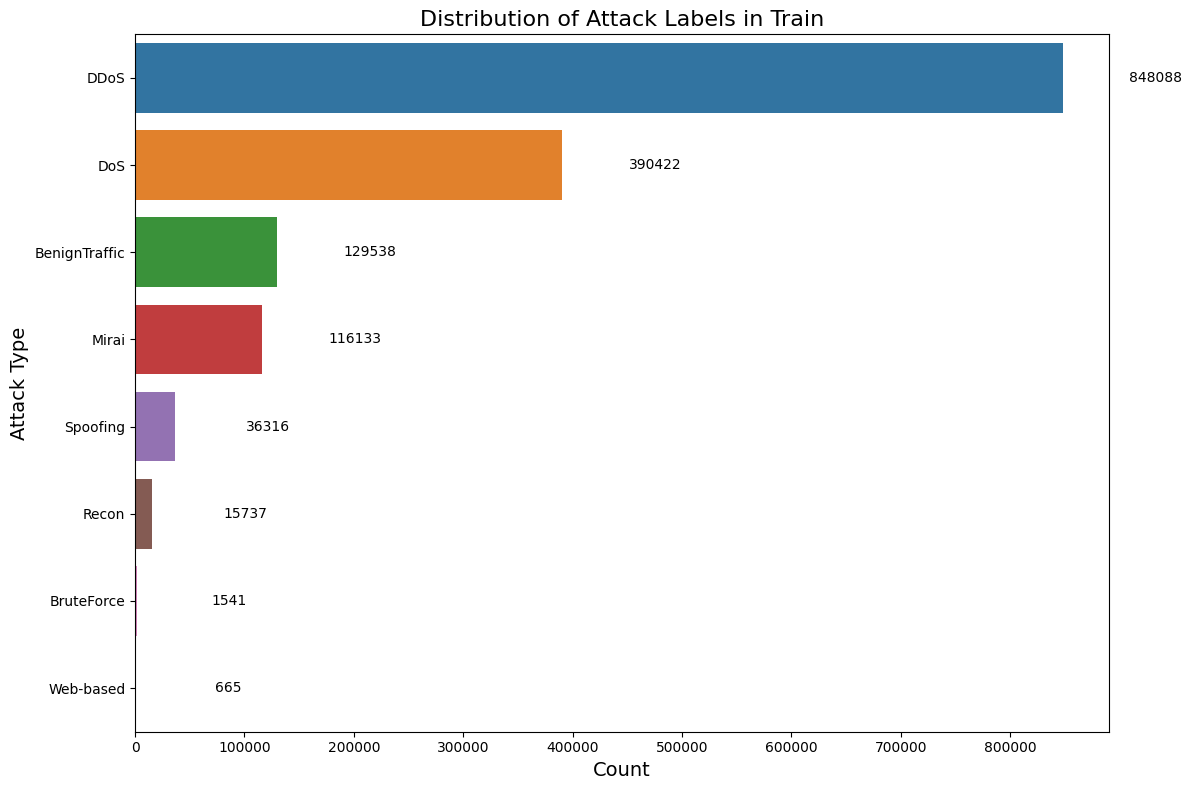

In [8]:
target_col = 'label'
plt.figure(figsize=(12, 8))
ax = sns.countplot(data_train, y=target_col, order=data_train[target_col].value_counts().index)

# 3. Add annotations and styling
plt.title('Distribution of Attack Labels in Train', fontsize=16)
plt.xlabel('Count', fontsize=14)
plt.ylabel('Attack Type', fontsize=14)

# Add count values on each bar
for p in ax.patches:
    width = p.get_width()
    plt.text(width + 0.1 * max(data_train[target_col].value_counts()), 
             p.get_y() + p.get_height()/2., 
             f'{int(width)}', 
             ha='center', va='center')

plt.tight_layout()
plt.show()

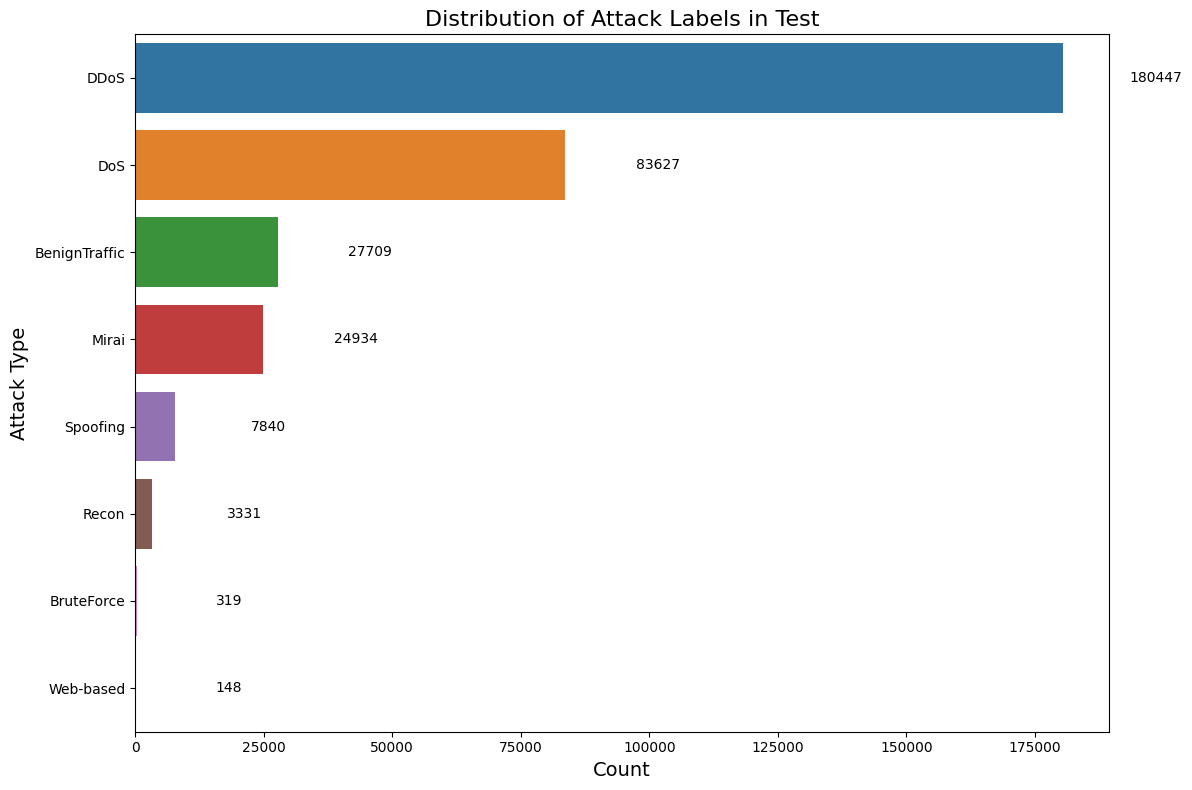

In [9]:
target_col = 'label'
plt.figure(figsize=(12, 8))
ax = sns.countplot(data_test, y=target_col, order=data_test[target_col].value_counts().index)

# 3. Add annotations and styling
plt.title('Distribution of Attack Labels in Test', fontsize=16)
plt.xlabel('Count', fontsize=14)
plt.ylabel('Attack Type', fontsize=14)

# Add count values on each bar
for p in ax.patches:
    width = p.get_width()
    plt.text(width + 0.1 * max(data_test[target_col].value_counts()), 
             p.get_y() + p.get_height()/2., 
             f'{int(width)}', 
             ha='center', va='center')

plt.tight_layout()
plt.show()

In [10]:
from sklearn.preprocessing import LabelEncoder

# Initialize LabelEncoder
label_encoder = LabelEncoder()

# Apply encoding to both train and test sets
data_train['label'] = label_encoder.fit_transform(data_train['label'])
data_test['label'] = label_encoder.transform(data_test['label'])  # Use same encoder
data_val['label'] = label_encoder.transform(data_val['label'])
# Verify the mapping
print("Label Classes Mapping:")
for i, class_name in enumerate(label_encoder.classes_):
    print(f"{class_name}: {i}")

# Check encoded labels
print("\nEncoded labels in training set:", data_train['label'].unique())

Label Classes Mapping:
BenignTraffic: 0
BruteForce: 1
DDoS: 2
DoS: 3
Mirai: 4
Recon: 5
Spoofing: 6
Web-based: 7

Encoded labels in training set: [4 2 0 3 5 6 1 7]


In [11]:
# Train set
X_train = data_train.drop('label', axis=1)
y_train = data_train['label']

# Validation set
X_val = data_val.drop('label', axis=1)
y_val = data_val['label']

# Test set
X_test = data_test.drop('label', axis=1)
y_test = data_test['label']


### Normalization

In [12]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_val_scaled = scaler.transform(X_val)


[0]	train-mlogloss:1.70250	validation-mlogloss:1.70249
[10]	train-mlogloss:0.50285	validation-mlogloss:0.50305
[20]	train-mlogloss:0.19346	validation-mlogloss:0.19373
[30]	train-mlogloss:0.08455	validation-mlogloss:0.08489
[40]	train-mlogloss:0.04418	validation-mlogloss:0.04459
[50]	train-mlogloss:0.02874	validation-mlogloss:0.02927
[60]	train-mlogloss:0.02244	validation-mlogloss:0.02308
[70]	train-mlogloss:0.01973	validation-mlogloss:0.02048
[80]	train-mlogloss:0.01826	validation-mlogloss:0.01910
[90]	train-mlogloss:0.01738	validation-mlogloss:0.01833
[100]	train-mlogloss:0.01661	validation-mlogloss:0.01771
[110]	train-mlogloss:0.01593	validation-mlogloss:0.01720
[120]	train-mlogloss:0.01538	validation-mlogloss:0.01682
[130]	train-mlogloss:0.01493	validation-mlogloss:0.01654
[140]	train-mlogloss:0.01446	validation-mlogloss:0.01628
[150]	train-mlogloss:0.01409	validation-mlogloss:0.01608
[160]	train-mlogloss:0.01372	validation-mlogloss:0.01588
[170]	train-mlogloss:0.01336	validation-ml

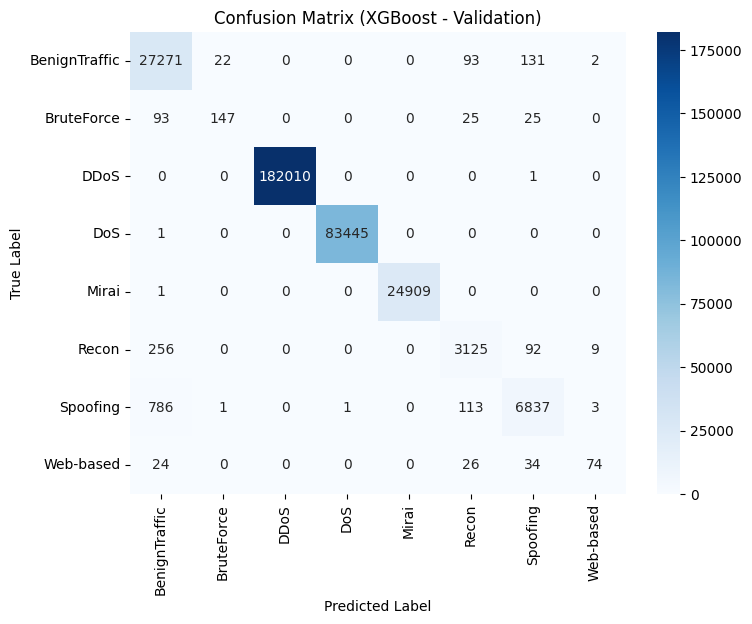


Accuracy: 0.9947
F1-Score (weighted): 0.9946


In [13]:
import xgboost as xgb
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
import seaborn as sns
import matplotlib.pyplot as plt

# X_train_scaled, y_train, X_val_scaled, y_val must be prepared before this

# 1. XGBoost parameters
params = {
    'objective': 'multi:softmax',          # Multi-class classification
    'num_class': len(label_encoder.classes_),  # Number of classes
    'eval_metric': 'mlogloss',            # Multiclass logloss
    'eta': 0.1,                           # Learning rate
    'max_depth': 6,                       # Tree depth
    'subsample': 0.8,                     # Random sample ratio per tree
    'colsample_bytree': 0.8,              # Feature sample ratio per tree
    'seed': 42,                           # Reproducibility
    'gamma': 0.1,                         # Minimum loss reduction for splitting
    'min_child_weight': 1                 # Minimum sum of instance weight
}

# 2. Convert to DMatrix (XGBoost's optimized format)
dtrain = xgb.DMatrix(X_train_scaled, label=y_train)
dval = xgb.DMatrix(X_val_scaled, label=y_val)

# 3. Training with Early Stopping, using Validation Set
evals = [(dtrain, 'train'), (dval, 'validation')]
model = xgb.train(
    params,
    dtrain,
    num_boost_round=200,
    evals=evals,
    early_stopping_rounds=20,
    verbose_eval=10
)

# 4. Predict on Validation Set (or Test if you're evaluating generalization later)
y_pred = model.predict(dval).astype(int)

# 5. Evaluation
print("\nClassification Report:")
print(classification_report(y_val, y_pred, target_names=label_encoder.classes_))

# 6. Confusion Matrix Plot
cm = confusion_matrix(y_val, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (XGBoost - Validation)')
plt.show()

# 7. Accuracy and F1 Score
print(f"\nAccuracy: {accuracy_score(y_val, y_pred):.4f}")
print(f"F1-Score (weighted): {f1_score(y_val, y_pred, average='weighted'):.4f}")


I0000 00:00:1745309175.478329      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1745309175.478925      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Starting VGG16 feature extraction for 100 samples...



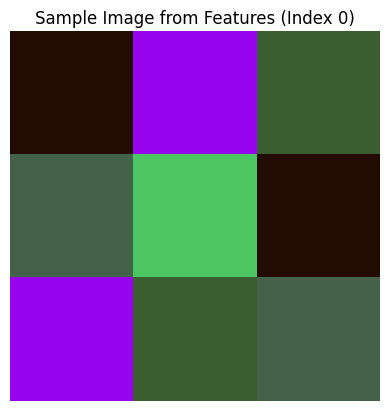

I0000 00:00:1745309177.687246      66 service.cc:148] XLA service 0x79ef58006870 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1745309177.688038      66 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1745309177.688057      66 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1745309177.822273      66 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1745309180.135623      66 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


Processed 100/100 - 0.07 sec per sample

Finished in 9.38 seconds.
Starting VGG16 feature extraction for 20 samples...



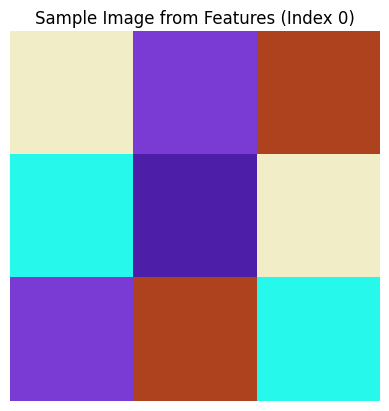

Processed 20/20 - 0.07 sec per sample

Finished in 1.41 seconds.

VGG16 Train Feature Shape: (100, 512)
VGG16 Test Feature Shape: (20, 512)
Epoch 1/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 75ms/step - accuracy: 0.6204 - loss: 0.7390 - val_accuracy: 0.3000 - val_loss: 0.8241
Epoch 2/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6469 - loss: 0.5817 - val_accuracy: 0.3500 - val_loss: 0.9551
Epoch 3/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8071 - loss: 0.4883 - val_accuracy: 0.5000 - val_loss: 0.7580
Epoch 4/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7937 - loss: 0.4530 - val_accuracy: 0.4500 - val_loss: 0.9400
Epoch 5/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8184 - loss: 0.3903 - val_accuracy: 0.6500 - val_loss: 0.7863
Epoch 6/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8096 - loss: 0.4259 - val_accuracy: 0.5000 - val_loss: 0.8686
Epoch 7/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8183 - loss: 0.4218 - val_accuracy: 0.5

In [14]:
import numpy as np
import pandas as pd
import time
import matplotlib.pyplot as plt
from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from PIL import Image

# Dummy: Simulate your features-to-image function
def features_to_rgb_image(features):
    """
    Converts a numeric feature vector into a dummy RGB image.
    """
    img_size = int(np.ceil(np.sqrt(len(features) / 3)))
    flat = np.tile(features, img_size * img_size * 3 // len(features) + 1)[:img_size * img_size * 3]
    img = flat.reshape((img_size, img_size, 3))
    img = (img * 255).astype(np.uint8)  # Scale to 0-255
    return Image.fromarray(img)

# Load pre-trained VGG16 model
base_model = VGG16(weights='imagenet', include_top=False, pooling='avg')

def extract_vgg16_features(img):
    """Extract features from an image using pre-trained VGG16."""
    img = img.resize((224, 224))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    processed_img = preprocess_input(img_array)
    features = base_model.predict(processed_img, verbose=0)
    return features.flatten()

def create_vgg16_feature_dataset(top_15_df):
    """Convert DataFrame of feature vectors into VGG16 feature matrix."""
    vgg16_features_list = []
    total = len(top_15_df)
    print(f"Starting VGG16 feature extraction for {total} samples...\n")
    start_time = time.time()

    for index, row in top_15_df.iterrows():
        t0 = time.time()
        feature_vector = row.values
        img = features_to_rgb_image(feature_vector)

        # Display the first sample image
        if index == 0:
            plt.imshow(img)
            plt.title(f"Sample Image from Features (Index {index})")
            plt.axis('off')
            plt.show()

        vgg16_features = extract_vgg16_features(img)
        vgg16_features_list.append(vgg16_features)
        print(f"Processed {index + 1}/{total} - {time.time() - t0:.2f} sec per sample", end="\r")

    print(f"\n\nFinished in {time.time() - start_time:.2f} seconds.")
    return np.array(vgg16_features_list)

# Dummy DataFrames simulating your real data
num_train_samples = 100
num_test_samples = 20
num_features = 15  # Matching your 'top_15' features

top_15_data_train = pd.DataFrame(np.random.rand(num_train_samples, num_features))
top_15_data_test = pd.DataFrame(np.random.rand(num_test_samples, num_features))

# Dummy labels for binary classification
y_train = np.random.randint(0, 2, size=(num_train_samples,))
y_test = np.random.randint(0, 2, size=(num_test_samples,))

# Extract VGG16 features
vgg16_train_features = create_vgg16_feature_dataset(top_15_data_train)
vgg16_test_features = create_vgg16_feature_dataset(top_15_data_test)

print("\nVGG16 Train Feature Shape:", vgg16_train_features.shape)
print("VGG16 Test Feature Shape:", vgg16_test_features.shape)

# Simple model for classification
model = Sequential([
    Dense(128, activation='relu', input_shape=(512,)),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the model
model.fit(vgg16_train_features, y_train, epochs=10, batch_size=8, validation_data=(vgg16_test_features, y_test))
